# Clase 9 - Introducción a Machine Learning
## Live Coding: nuestro primer modelo predictivo

Dataset: `viviendas.csv`

**Instrucciones:** cada celda de código está comentada (`#`). Ve descomentando los bloques en el orden de la presentación, uno a la vez, y ejecuta para ir construyendo el modelo frente al grupo.

## Paso 1: Cargar los datos

In [1]:
import pandas as pd
#
df = pd.read_csv("../data/viviendas.csv")
#
print(df.head())
print(df.shape)
df.info()

   metros  habitaciones  banios  antiguedad   precio
0   139.9             2       1         6.0  3123000
1   114.5             2       1        12.0  2768000
2   145.9             3       1         1.0  3249000
3   180.9             4       2        16.0  4286000
4   110.6             1       3         6.0  2740000
(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   metros        1000 non-null   float64
 1   habitaciones  1000 non-null   int64  
 2   banios        1000 non-null   int64  
 3   antiguedad    992 non-null    float64
 4   precio        1000 non-null   int64  
dtypes: float64(2), int64(3)
memory usage: 39.2 KB


## Paso 2: Exploración rápida
Antes de modelar: valores faltantes, tipos, distribuciones y correlaciones.

In [91]:
print(df.describe())
#
print(df.isna().sum())
#
print(df.corr(numeric_only=True))

df = df.dropna()

print(df.isna().sum())

            metros  habitaciones       banios  antiguedad        precio
count  1000.000000   1000.000000  1000.000000  992.000000  1.000000e+03
mean    120.922000      3.111000     2.088000   12.173387  3.059096e+06
std      38.793875      1.029436     0.941883    8.313617  7.375896e+05
min      35.000000      1.000000     1.000000    0.000000  1.073000e+06
25%      94.075000      2.000000     1.000000    6.000000  2.531000e+06
50%     121.000000      3.000000     2.000000   10.000000  3.067000e+06
75%     145.900000      4.000000     3.000000   16.000000  3.562250e+06
max     274.100000      5.000000     4.000000   45.000000  5.711000e+06
metros          0
habitaciones    0
banios          0
antiguedad      8
precio          0
dtype: int64
                metros  habitaciones    banios  antiguedad    precio
metros        1.000000      0.032393  0.002393   -0.001724  0.951765
habitaciones  0.032393      1.000000  0.003337    0.023728  0.236188
banios        0.002393      0.003337  1.00

## Paso 3: Definir X (features)

In [107]:
X = df[
    [
        "metros",
        "habitaciones",
        "banios",
        "antiguedad"
    ]
]

## Paso 4: Definir y (variable objetivo)

In [122]:
y = df["precio"]

## Paso 5: Train / Test Split

In [136]:
from sklearn.model_selection import train_test_split
#
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
#
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(793, 4)
(199, 4)
(793,)
(199,)


## Paso 6: Crear el modelo (Regresión Lineal)

In [149]:
from sklearn.linear_model import LinearRegression
#
modelo = LinearRegression()

## Paso 7: Entrenar el modelo

In [161]:
modelo.fit(
    X_train,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Paso 8: Predecir sobre Test

In [172]:
predicciones = modelo.predict(X_test)
#
print(predicciones[:10])

[3700494.81019127 2866023.23127126 2415813.54808159 2619996.87180555
 2772071.83519562 3760684.74614989 3459514.43914086 3281819.66718083
 3759633.89273903 2644041.11030184]


## Paso 9: Comparar real vs predicción

In [182]:
comparacion = pd.DataFrame({
    "Real": y_test,
    "Prediccion": predicciones
})
#
print(comparacion.head(10))

        Real    Prediccion
213  3804000  3.700495e+06
332  2868000  2.866023e+06
507  2577000  2.415814e+06
310  2485000  2.619997e+06
88   2566000  2.772072e+06
542  3592000  3.760685e+06
281  3480000  3.459514e+06
107  3374000  3.281820e+06
59   3924000  3.759634e+06
512  2679000  2.644041e+06


## Evaluación: MAE

In [191]:
from sklearn.metrics import mean_absolute_error
#
mae = mean_absolute_error(
    y_test,
    predicciones
)
#
print("MAE:", mae)

MAE: 122169.72571830302


## Evaluación: RMSE

In [199]:
from sklearn.metrics import mean_squared_error
#
rmse = (
    mean_squared_error(
        y_test,
        predicciones
    ) ** 0.5
)
#
print("RMSE:", rmse)

RMSE: 153975.24431207145


## Evaluación: R²

In [206]:
from sklearn.metrics import r2_score
#
r2 = r2_score(
    y_test,
    predicciones
)
#
print("R2:", r2)

R2: 0.9543142465506268


## Visualización: Real vs Predicción

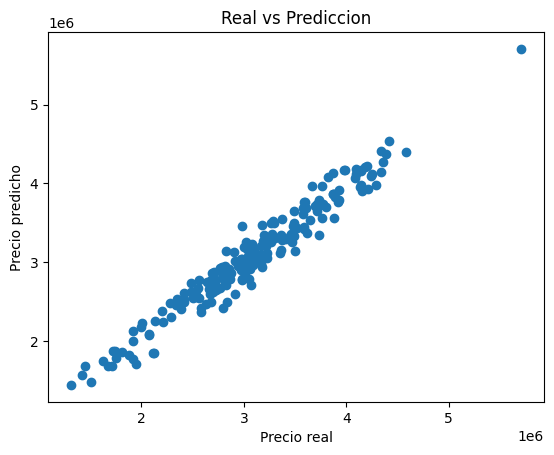

In [212]:
import matplotlib.pyplot as plt
#
plt.scatter(y_test, predicciones)
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Real vs Prediccion")
plt.show()

## Train vs Test: ¿hay overfitting?

In [217]:
pred_train = modelo.predict(X_train)
#
mae_train = mean_absolute_error(
    y_train,
    pred_train
)

In [221]:
pred_test = modelo.predict(X_test)
#
mae_test = mean_absolute_error(
    y_test,
    pred_test
)
#
print("MAE Train:", mae_train)
print("MAE Test:", mae_test)

MAE Train: 115510.97910940062
MAE Test: 122169.72571830302


## Baseline: ¿el modelo agrega valor?

In [224]:
media_train = y_train.mean()
#
pred_baseline = [media_train] * len(y_test)
#
mae_baseline = mean_absolute_error(
    y_test,
    pred_baseline
)
#
print("Baseline:", mae_baseline)

Baseline: 563476.7532492222


## Predecir una vivienda nueva
110 m², 3 habitaciones, 2 baños, 8 años de antigüedad.

In [226]:
nueva = pd.DataFrame({
    "metros": [110],
    "habitaciones": [3],
    "banios": [2],
    "antiguedad": [8]
})

precio_estimado = modelo.predict(nueva)

print(precio_estimado)

[2856816.05798756]
